# **Exploratory Data Analysis (EDA)** - Bank Fraud Analysis

### Overview

This notebook presents the Exploratory Data Analysis (EDA) of the cleaned Bank Fraud dataset. The objective of this analysis is to understand the underlying characteristics of the data, identify meaningful patterns, uncover relationships between variables, and derive insights related to fraudulent transactions.

The analysis includes statistical summaries, univariate and bivariate analyses, correlation analysis, and a variety of visualizations to better understand customer behavior, transaction characteristics, and fraud trends. The findings from this notebook will also serve as the foundation for the interactive Streamlit dashboard developed later in the project.

### Objectives

The primary objectives of this notebook are:
- Understand the overall structure and characteristics of the cleaned dataset.
- Perform descriptive statistical analysis.
- Explore the distribution of numerical and categorical features.
- Analyze fraudulent and non-fraudulent transactions.
- Identify relationships between different variables.
- Discover patterns and trends that may indicate fraudulent activities.
- Generate insights to support the development of an interactive dashboard.

## Import Required Libraries
The following libraries are imported to perform data manipulation, statistical analysis, and data visualization throughout this notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load the Cleaned Dataset

The cleaned dataset generated during the data preprocessing stage is loaded into a Pandas DataFrame. This dataset will be used for all subsequent exploratory analyses.

In [3]:
df = pd.read_csv("../data/processed/bank_fraud_cleaned.csv")

## Dataset Overview

Before performing detailed analysis, it is important to examine the overall structure of the dataset. This includes checking the number of observations, available features, data types, and a preview of the records to gain a better understanding of the data.

In [4]:
df.head()

,transaction_id,customer_id,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,...,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,transaction_datetime
0,TXN0000000001,CUST00121959,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,...,157,23,52.7,10.20,0,0,0,0,No Fraud,2023-08-17 21:13:00
1,TXN0000000002,CUST00146868,5,0,1,UK,New York,Healthcare,Cheque,Desktop,...,153,23,0.9,12.47,0,0,0,0,No Fraud,2024-02-06 05:16:00
2,TXN0000000003,CUST00131933,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,...,161,20,9.2,0.08,0,1,0,0,No Fraud,2024-06-28 12:15:00
3,TXN0000000004,CUST00103695,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,...,160,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023-03-16 02:53:00
4,TXN0000000005,CUST00119880,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,...,134,18,38.9,2.16,0,0,0,0,No Fraud,2024-07-12 12:39:00


In [5]:
df.shape

(1000000, 25)

In [6]:
df.columns

Index(['transaction_id', 'customer_id', 'hour_of_day', 'is_weekend',
       'is_night_transaction', 'country', 'city', 'merchant_category',
       'payment_method', 'device_type', 'customer_age', 'credit_score',
       'account_age_years', 'account_balance', 'transaction_amount',
       'num_prev_transactions', 'transaction_freq_monthly',
       'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international',
       'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type',
       'transaction_datetime'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   hour_of_day               1000000 non-null  int64  
 3   is_weekend                1000000 non-null  int64  
 4   is_night_transaction      1000000 non-null  int64  
 5   country                   1000000 non-null  object 
 6   city                      1000000 non-null  object 
 7   merchant_category         1000000 non-null  object 
 8   payment_method            1000000 non-null  object 
 9   device_type               1000000 non-null  object 
 10  customer_age              1000000 non-null  int64  
 11  credit_score              1000000 non-null  int64  
 12  account_age_years         1000000 non-null  float64
 13  account_balance           10

#### Observation

The dataset contains **1,000,000 transaction records** and **26 features** describing customer information, transaction details, and fraud-related attributes.

The dataset consists of numerical, categorical, and binary variables. All columns have appropriate data types, and no missing values are present after the data cleaning process.

## Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset by calculating measures such as count, mean, standard deviation, minimum, maximum, and quartiles. Examining these statistics helps identify the overall distribution of numerical features and highlights potential anomalies or extreme values that may require further investigation.

In [8]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


#### Observation

The statistical summary provides an overview of the central tendency and variability of the numerical variables. Differences between the mean, median (50th percentile), and extreme values may indicate skewed distributions or the presence of outliers. These characteristics will be explored further using visualizations in the subsequent sections.

### Numerical Features

The dataset contains the following numerical features, which will be analyzed to understand their distributions, variability, and relationship with fraudulent transactions.

In [9]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
numerical_columns

Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud'],
      dtype='object')

### Categorical Features

Categorical features describe qualitative information such as customer location, merchant category, payment method, and fraud type. These variables will be analyzed using frequency distributions and categorical visualizations.

In [10]:
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['transaction_id', 'customer_id', 'country', 'city', 'merchant_category',
       'payment_method', 'device_type', 'fraud_type', 'transaction_datetime'],
      dtype='object')

## Univariate Analysis

Univariate analysis focuses on examining one variable at a time to understand its distribution, central tendency, spread, and potential outliers. This analysis provides valuable insights into the characteristics of individual features before exploring relationships between multiple variables.

### Distribution of Transaction Amount

Transaction amount is one of the most important financial variables in the dataset. Analyzing its distribution helps identify common transaction ranges, detect skewness, and reveal unusually large or small transactions that may require further investigation.

#### Analysis Objective

To examine the distribution of transaction amounts, identify potential skewness and outliers, and understand the overall spending patterns within the dataset.

In [11]:
df["transaction_amount"].describe()

count    1000000.000000
mean         204.724665
std          459.567802
min            1.000000
25%           33.400000
50%           73.120000
75%          181.450000
max        46129.600000
Name: transaction_amount, dtype: float64

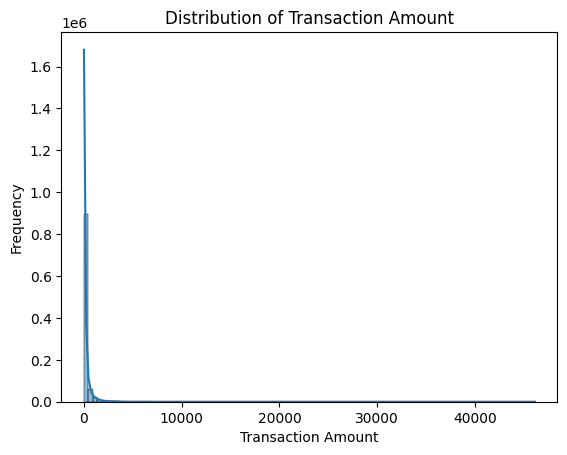

In [12]:
sns.histplot(
    df["transaction_amount"],
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

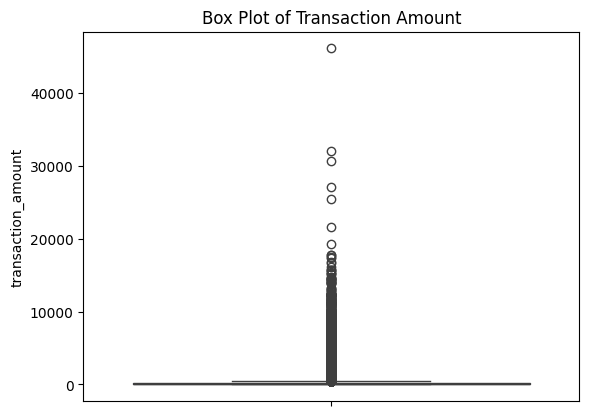

In [13]:
sns.boxplot(
    df["transaction_amount"]
)

plt.title("Box Plot of Transaction Amount")

plt.show()

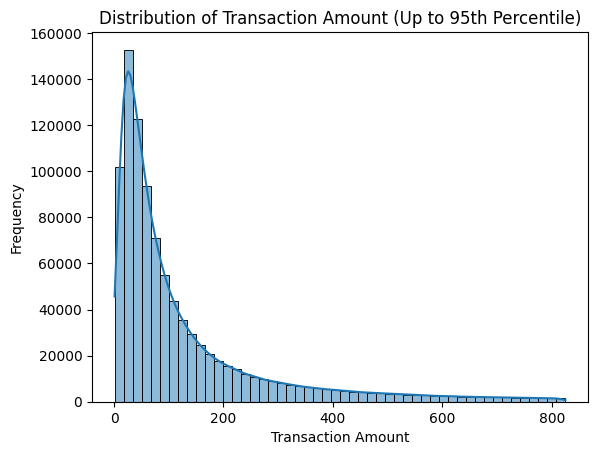

In [14]:
limit = df["transaction_amount"].quantile(0.95)

sns.histplot(
    df[df["transaction_amount"] <= limit]["transaction_amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount (Up to 95th Percentile)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

#### Observation

- Transaction amounts are highly right-skewed.
- Most transactions are concentrated within the lower transaction range.
- A small number of transactions have exceptionally high values, resulting in numerous outliers.
- The mean transaction amount is significantly higher than the median, indicating the influence of these high-value transactions.